# Chapter Number Sequence — Visual Checker
Visualises `chapter_number` progressions for **full** and **interim** constitutions in `sections_v2.csv`.

In [1]:
import csv
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

CSV_PATH = Path("../output/sections_v2.csv")

In [2]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
print(df.shape)
df.head(3)

(2796, 17)


,section_id,doc_id,doc_type,year_th,year_ce,name_short,era,regime_type,parent_doc_id,chapter_number,chapter_title,section_number,section_role,target_chapter,target_section_no,change_mode,text
0,const_2475_s_1,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,0,บททั่วไป,1,content,NaN,NaN,content,สยามประเทศเป็นราชอาณาจักรอันหนึ่งอันเดียว จะแบ...
1,const_2475_s_2,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,0,บททั่วไป,2,content,NaN,NaN,content,อำนาจอธิปไตยย่อมมาจากปวงชนชาวสยาม พระมหากษัตริ...
2,const_2475_s_3,const_2475,full,2475,1932,Constitution 2475,early_democracy,civilian,NaN,1,พระมหากษัตริย์,3,content,NaN,NaN,content,องค์พระมหากษัตริย์ดำรงอยู่ในฐานะอันเป็นที่เคาร...


## 1 · Section count per document (full & interim)

/var/folders/mb/pnwt1wh177lc4ny5xbs_cyxc0000gn/T/ipykernel_1837/389264045.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts["doc_id"], rotation=45, ha="right", fontsize=8)


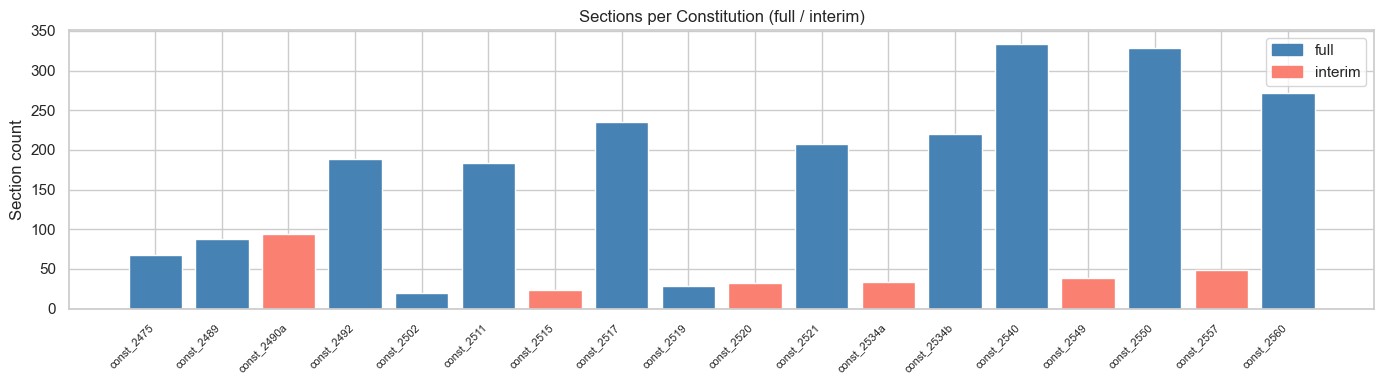

In [3]:
fi = df[df["doc_type"].isin(["full", "interim"])].copy()
counts = fi.groupby(["doc_id", "doc_type"]).size().reset_index(name="sections")
counts = counts.sort_values("doc_id")

palette = {"full": "steelblue", "interim": "salmon"}
colors = counts["doc_type"].map(palette)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(counts["doc_id"], counts["sections"], color=colors)
ax.set_xticklabels(counts["doc_id"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Section count")
ax.set_title("Sections per Constitution (full / interim)")
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()

## 2 · Chapter number distribution per document (box plot)

/var/folders/mb/pnwt1wh177lc4ny5xbs_cyxc0000gn/T/ipykernel_1837/2677025038.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/mb/pnwt1wh177lc4ny5xbs_cyxc0000gn/T/ipykernel_1837/2677025038.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)


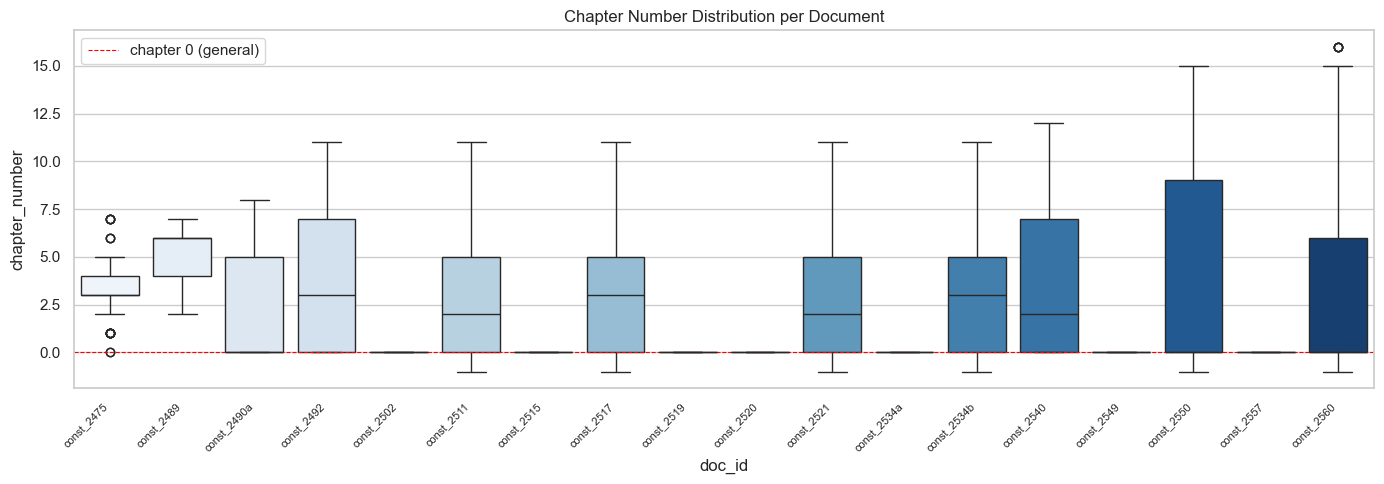

In [4]:
fi["chapter_number"] = pd.to_numeric(fi["chapter_number"], errors="coerce")

order = sorted(fi["doc_id"].unique())
fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(
    data=fi, x="doc_id", y="chapter_number",
    order=order, ax=ax, palette="Blues"
)
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="chapter 0 (general)")
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("chapter_number")
ax.set_title("Chapter Number Distribution per Document")
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Sequence transition heatmap (chapter per section index)
Each row = one document. X-axis = section index within that doc. Colour = chapter number.

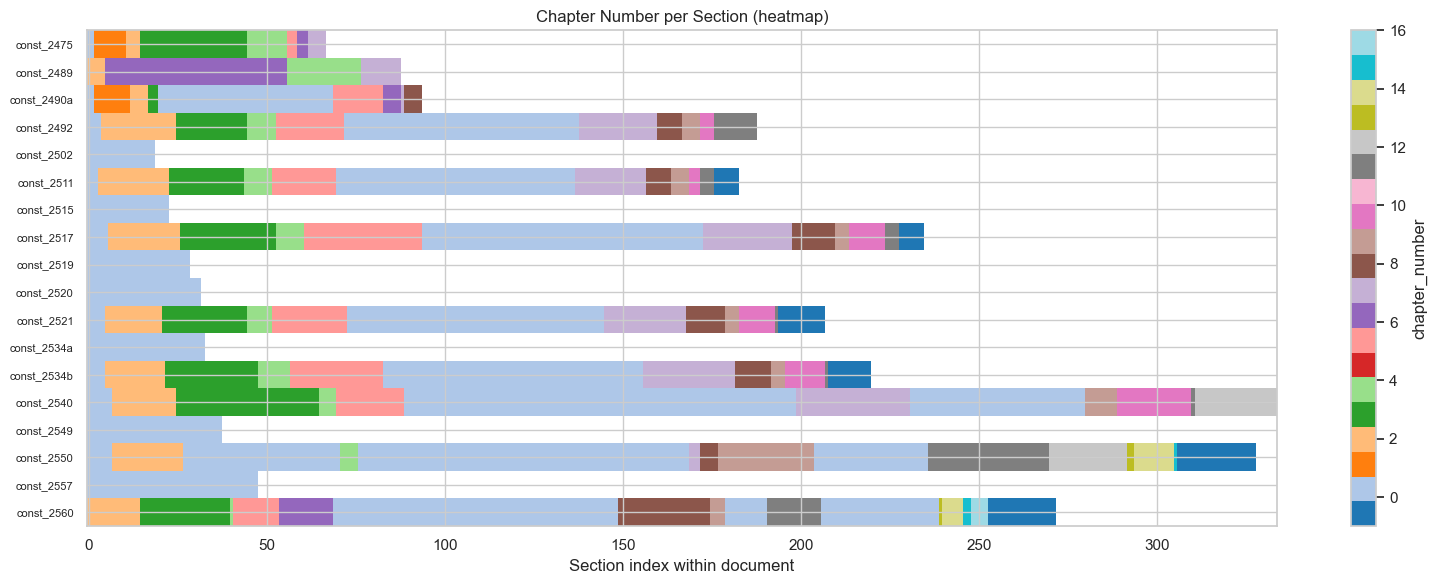

In [5]:
docs = sorted(fi["doc_id"].unique())
max_len = fi.groupby("doc_id").size().max()

matrix = np.full((len(docs), max_len), np.nan)
for i, doc_id in enumerate(docs):
    chaps = fi[fi["doc_id"] == doc_id]["chapter_number"].values
    matrix[i, : len(chaps)] = chaps

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(matrix, aspect="auto", cmap="tab20", vmin=-1, vmax=16)
ax.set_yticks(range(len(docs)))
ax.set_yticklabels(docs, fontsize=8)
ax.set_xlabel("Section index within document")
ax.set_title("Chapter Number per Section (heatmap)")
plt.colorbar(im, ax=ax, label="chapter_number")
plt.tight_layout()
plt.show()

## 4 · Sequence anomaly detection
Flags `bad_start` (doesn't begin at 0), `jump` (skips a chapter), `drop` (chapter decreases non-reset), and `-1` (special/transitory sections).

In [6]:
anomaly_counts = defaultdict(lambda: defaultdict(int))

for doc_id in docs:
    chaps = fi[fi["doc_id"] == doc_id]["chapter_number"].tolist()
    chaps_num = [int(c) if pd.notna(c) else None for c in chaps]

    if chaps_num and chaps_num[0] != 0:
        anomaly_counts[doc_id]["bad_start"] += 1

    for prev, curr in zip(chaps_num, chaps_num[1:]):
        if prev is None or curr is None:
            anomaly_counts[doc_id]["null"] += 1
        elif curr == -1:
            anomaly_counts[doc_id]["-1 (special)"] += 1
        elif curr == prev + 1 or curr == 0:
            pass  # valid
        elif curr < prev:
            anomaly_counts[doc_id]["drop"] += 1
        elif curr > prev + 1:
            anomaly_counts[doc_id]["jump"] += 1

anomaly_df = pd.DataFrame(anomaly_counts).T.fillna(0).astype(int)
anomaly_df = anomaly_df.reindex(index=docs).fillna(0).astype(int)
anomaly_df

,bad_start,jump,drop,-1 (special)
const_2475,0,0,0,0
const_2489,1,2,1,0
const_2490a,0,1,0,0
const_2492,0,2,0,0
const_2502,0,0,0,0
const_2511,0,2,0,7
const_2515,0,0,0,0
const_2517,0,2,0,7
const_2519,0,0,0,0
const_2520,0,0,0,0


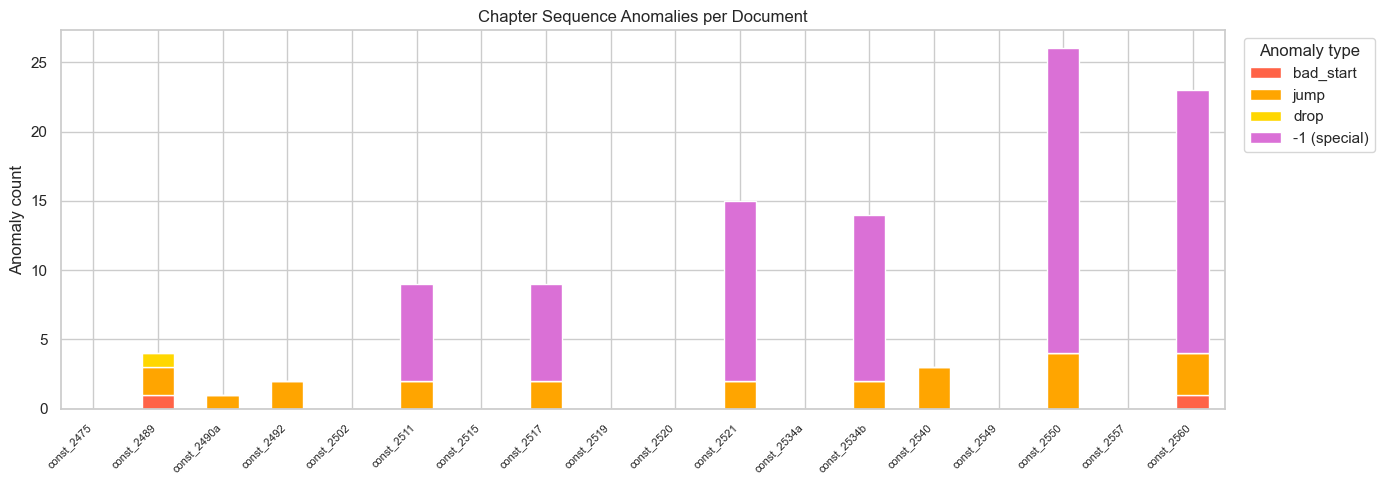

In [7]:
if anomaly_df.empty or anomaly_df.values.sum() == 0:
    print("No anomalies found.")
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    anomaly_df.plot(kind="bar", stacked=True, ax=ax,
                    color=["tomato", "orange", "gold", "orchid", "steelblue"])
    ax.set_xticklabels(anomaly_df.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Anomaly count")
    ax.set_title("Chapter Sequence Anomalies per Document")
    ax.legend(title="Anomaly type", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 5 · Per-document line chart — chapter progression
Shows exact chapter_number value at each section index for each constitution.

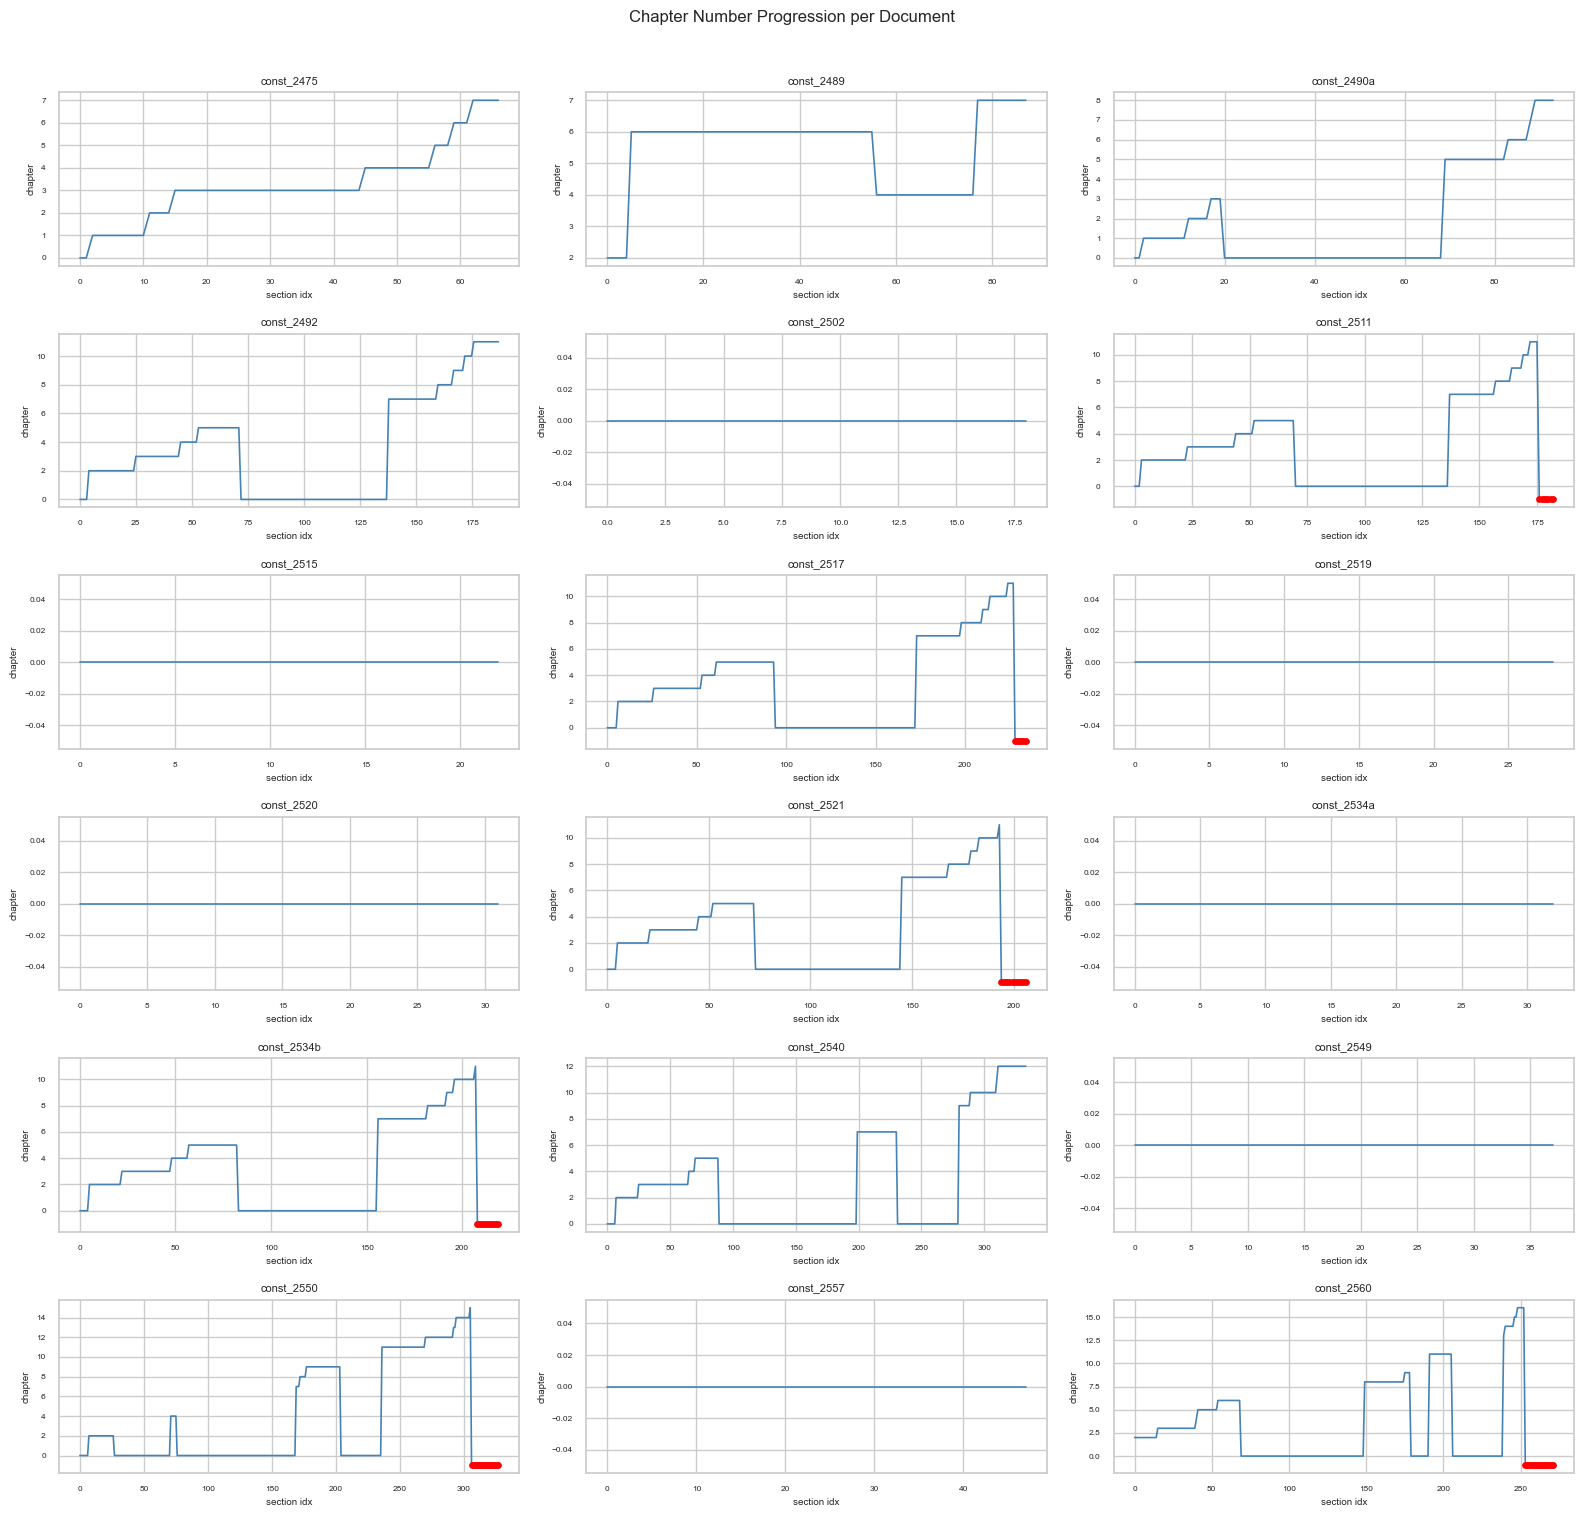

In [8]:
ncols = 3
nrows = int(np.ceil(len(docs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.5))
axes = axes.flatten()

for i, doc_id in enumerate(docs):
    sub = fi[fi["doc_id"] == doc_id].reset_index(drop=True)
    ax = axes[i]
    ax.plot(sub.index, sub["chapter_number"], linewidth=1.2, color="steelblue")
    # mark -1 in red
    neg = sub[sub["chapter_number"] == -1]
    ax.scatter(neg.index, neg["chapter_number"], color="red", s=15, zorder=5, label="-1")
    ax.set_title(doc_id, fontsize=8)
    ax.set_xlabel("section idx", fontsize=7)
    ax.set_ylabel("chapter", fontsize=7)
    ax.tick_params(labelsize=6)

# hide unused subplots
for j in range(len(docs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Chapter Number Progression per Document", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()